In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sp500 = yf.download(["SPY"], '2000-01-01', '2025-12-31')
# sp500.to_csv("sp500.csv")

/tmp/ipykernel_2424/3176137748.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download(["SPY"], '2000-01-01', '2025-12-31')
[*********************100%***********************]  1 of 1 completed


In [3]:
bonds = yf.download(["AGG"], '2000-01-01', '2025-12-31')
bonds
# bonds.to_csv("bonds.csv")

/tmp/ipykernel_2424/3946027231.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bonds = yf.download(["AGG"], '2000-01-01', '2025-12-31')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AGG,AGG,AGG,AGG,AGG
Date,,,,,
2003-09-29,49.753372,49.816680,49.719285,49.811810,13600
2003-09-30,50.011490,50.030969,49.811835,49.816706,62600
2003-10-01,49.987148,50.035844,49.962798,49.982278,66300
2003-10-02,49.909214,49.987130,49.675472,49.767993,68900
2003-10-03,49.548866,49.694958,49.524516,49.694958,64500
...,...,...,...,...,...
2025-12-23,98.829422,98.849224,98.611560,98.631363,9744100
2025-12-24,99.047279,99.067089,98.878934,98.928451,4483900


In [4]:
gold = yf.download(["GLD"], '2000-01-01', '2025-12-31')
gold
# gold.to_csv("gold.csv")

/tmp/ipykernel_2424/4283404768.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download(["GLD"], '2000-01-01', '2025-12-31')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GLD,GLD,GLD,GLD,GLD
Date,,,,,
2004-11-18,44.380001,44.490002,44.070000,44.430000,5992000
2004-11-19,44.779999,44.919998,44.470001,44.490002,11655300
2004-11-22,44.950001,44.970001,44.740002,44.750000,11996000
2004-11-23,44.750000,44.919998,44.720001,44.880001,3169200
2004-11-24,45.049999,45.049999,44.790001,44.930000,6105100
...,...,...,...,...,...
2025-12-23,413.640015,413.760010,407.100006,410.299988,13193300
2025-12-24,411.929993,412.630005,408.829987,412.250000,6718400


In [5]:
df = sp500.join(gold).join(bonds)
df

Price,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,GLD,GLD,GLD,GLD,GLD,AGG,AGG,AGG,AGG,AGG
Date,,,,,,,,,,,,,,,
2000-01-03,91.367508,93.134391,90.385906,93.134391,8164300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,87.794487,90.503709,87.725775,90.169964,8089800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,87.951561,88.913531,86.223941,87.912297,12177900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,86.538055,88.893901,86.538055,87.715978,6227200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,91.563873,91.563873,87.990840,88.147897,8066500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,686.086304,686.325640,682.007416,682.057268,64840000,413.640015,413.760010,407.100006,410.299988,13193300.0,98.829422,98.849224,98.611560,98.631363,9744100.0
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,411.929993,412.630005,408.829987,412.250000,6718400.0,99.047279,99.067089,98.878934,98.928451,4483900.0


In [6]:
prices = df["Close"]
prices.columns = ["SPY_Close", "GLD_Close", "AGG_Close"]
prices

,SPY_Close,GLD_Close,AGG_Close
Date,,,
2000-01-03,91.367508,NaN,NaN
2000-01-04,87.794487,NaN,NaN
2000-01-05,87.951561,NaN,NaN
2000-01-06,86.538055,NaN,NaN
2000-01-07,91.563873,NaN,NaN
...,...,...,...
2025-12-23,686.086304,413.640015,98.829422
2025-12-24,688.499695,411.929993,99.047279
2025-12-26,688.429871,416.739990,99.067093


In [7]:
prices.isnull().sum()

,0
SPY_Close,0
GLD_Close,1226
AGG_Close,938


In [8]:
prices = prices.dropna()
prices

,SPY_Close,GLD_Close,AGG_Close
Date,,,
2004-11-18,79.950714,44.380001,51.956501
2004-11-19,79.061928,44.779999,51.850304
2004-11-22,79.438957,44.950001,51.931271
2004-11-23,79.560158,44.750000,51.900871
2004-11-24,79.748703,45.049999,51.951488
...,...,...,...
2025-12-23,686.086304,413.640015,98.829422
2025-12-24,688.499695,411.929993,99.047279
2025-12-26,688.429871,416.739990,99.067093


In [9]:
prices = prices.reset_index()
prices

,Date,SPY_Close,GLD_Close,AGG_Close
0,2004-11-18,79.950714,44.380001,51.956501
1,2004-11-19,79.061928,44.779999,51.850304
2,2004-11-22,79.438957,44.950001,51.931271
3,2004-11-23,79.560158,44.750000,51.900871
4,2004-11-24,79.748703,45.049999,51.951488
...,...,...,...,...
5307,2025-12-23,686.086304,413.640015,98.829422
5308,2025-12-24,688.499695,411.929993,99.047279
5309,2025-12-26,688.429871,416.739990,99.067093
5310,2025-12-29,685.976562,398.600006,99.185928


In [10]:
prices.to_csv("market_daily.csv", index=False)

In [11]:
prices.tail()

,Date,SPY_Close,GLD_Close,AGG_Close
5307,2025-12-23,686.086304,413.640015,98.829422
5308,2025-12-24,688.499695,411.929993,99.047279
5309,2025-12-26,688.429871,416.739990,99.067093
5310,2025-12-29,685.976562,398.600006,99.185928
5311,2025-12-30,685.138916,398.890015,99.146317


<Axes: xlabel='Date'>

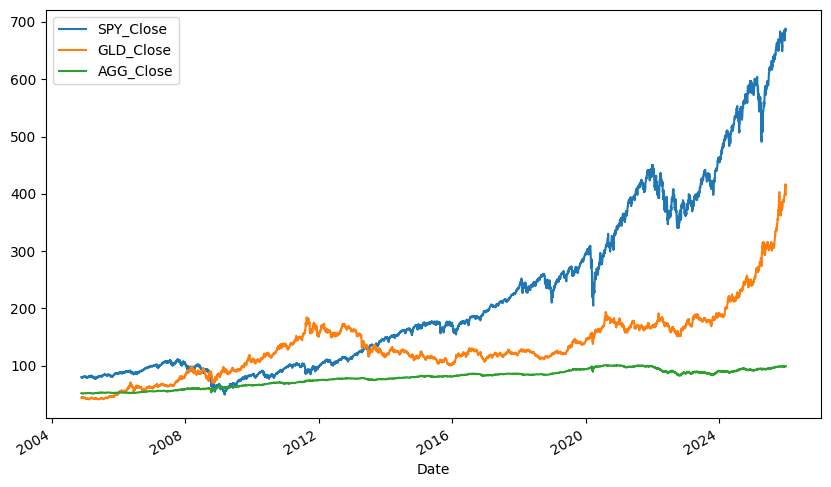

In [12]:
prices.set_index("Date")[["SPY_Close","GLD_Close","AGG_Close"]].plot(figsize=(10,6))

In [13]:
returns = prices.copy()

returns["SPY_Returns"] = prices["SPY_Close"].pct_change()
returns["GLD_Returns"] = prices["GLD_Close"].pct_change()
returns["AGG_Returns"] = prices["AGG_Close"].pct_change()
returns

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Returns,GLD_Returns,AGG_Returns
0,2004-11-18,79.950714,44.380001,51.956501,NaN,NaN,NaN
1,2004-11-19,79.061928,44.779999,51.850304,-0.011117,0.009013,-0.002044
2,2004-11-22,79.438957,44.950001,51.931271,0.004769,0.003796,0.001562
3,2004-11-23,79.560158,44.750000,51.900871,0.001526,-0.004449,-0.000585
4,2004-11-24,79.748703,45.049999,51.951488,0.002370,0.006704,0.000975
...,...,...,...,...,...,...,...
5307,2025-12-23,686.086304,413.640015,98.829422,0.004570,0.013252,0.000000
5308,2025-12-24,688.499695,411.929993,99.047279,0.003518,-0.004134,0.002204
5309,2025-12-26,688.429871,416.739990,99.067093,-0.000101,0.011677,0.000200
5310,2025-12-29,685.976562,398.600006,99.185928,-0.003564,-0.043528,0.001200


<Axes: xlabel='Date'>

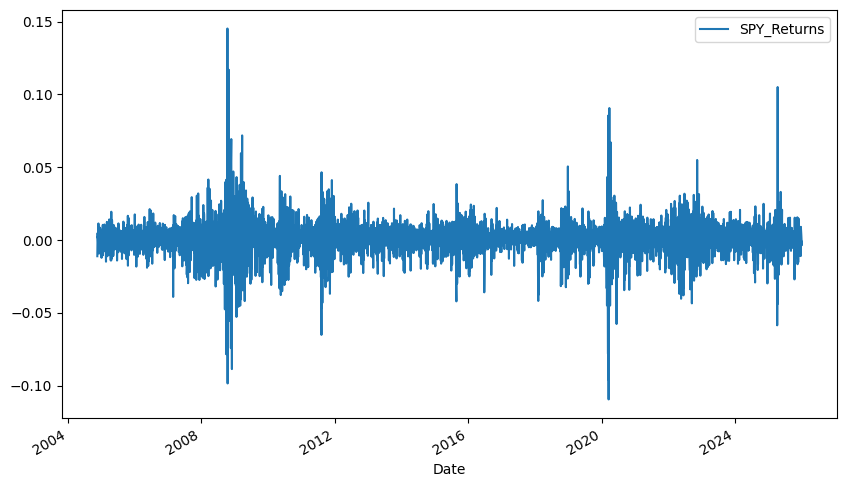

In [14]:
returns.set_index("Date")[["SPY_Returns"]].plot(figsize = (10, 6))

<Axes: xlabel='Date'>

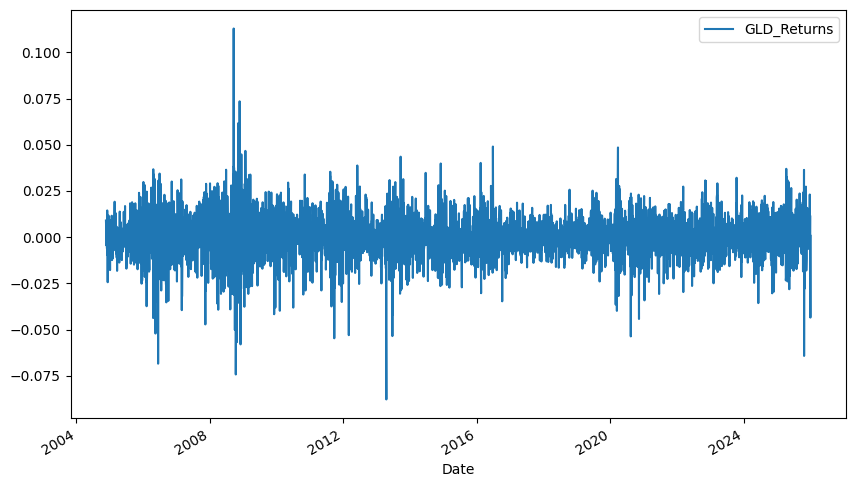

In [15]:
returns.set_index("Date")[["GLD_Returns"]].plot(figsize = (10, 6))

<Axes: xlabel='Date'>

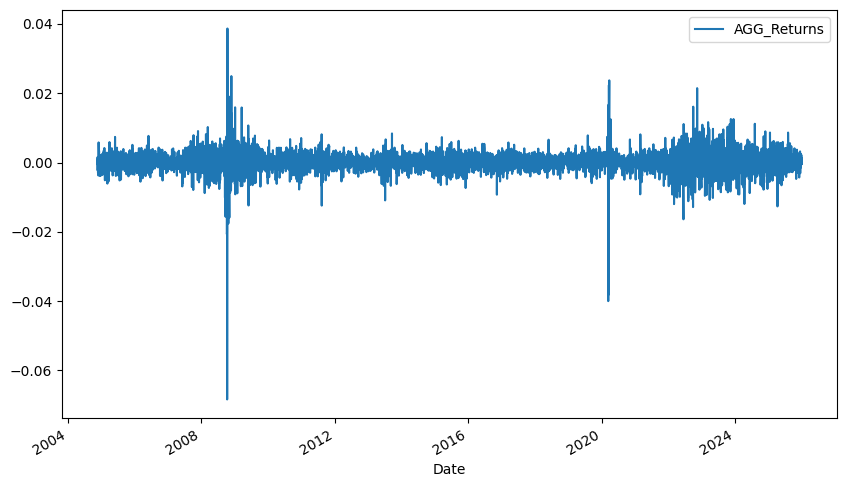

In [16]:
returns.set_index("Date")[["AGG_Returns"]].plot(figsize = (10, 6))

<Axes: xlabel='Date'>

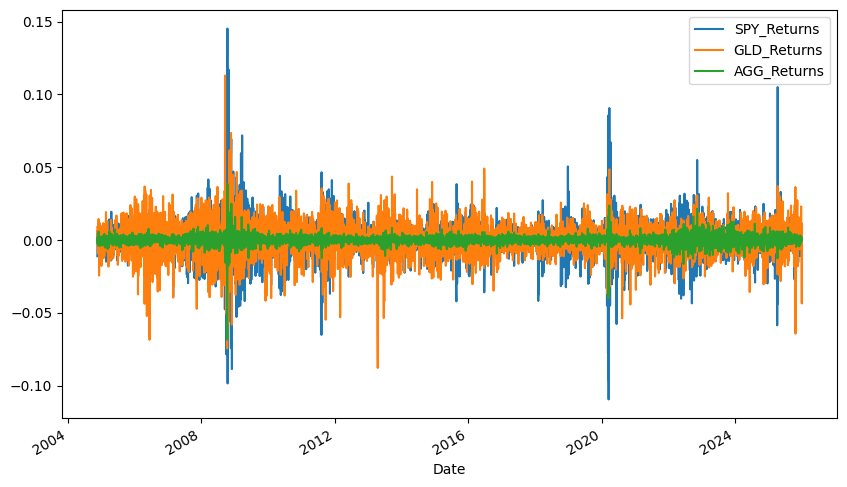

In [17]:
returns.set_index("Date")[["SPY_Returns", "GLD_Returns", "AGG_Returns"]].plot(figsize = (10, 6))

In [18]:
volatility = returns.copy()

volatility["SPY_Volatility"] = returns["SPY_Returns"].rolling(window=30).std()
volatility["GLD_Volatility"] = returns["GLD_Returns"].rolling(window=30).std()
volatility["AGG_Volatility"] = returns["AGG_Returns"].rolling(window=30).std()
volatility

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Returns,GLD_Returns,AGG_Returns,SPY_Volatility,GLD_Volatility,AGG_Volatility
0,2004-11-18,79.950714,44.380001,51.956501,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-11-19,79.061928,44.779999,51.850304,-0.011117,0.009013,-0.002044,NaN,NaN,NaN
2,2004-11-22,79.438957,44.950001,51.931271,0.004769,0.003796,0.001562,NaN,NaN,NaN
3,2004-11-23,79.560158,44.750000,51.900871,0.001526,-0.004449,-0.000585,NaN,NaN,NaN
4,2004-11-24,79.748703,45.049999,51.951488,0.002370,0.006704,0.000975,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
5307,2025-12-23,686.086304,413.640015,98.829422,0.004570,0.013252,0.000000,0.007670,0.008527,0.001904
5308,2025-12-24,688.499695,411.929993,99.047279,0.003518,-0.004134,0.002204,0.007684,0.008624,0.001867
5309,2025-12-26,688.429871,416.739990,99.067093,-0.000101,0.011677,0.000200,0.007685,0.008422,0.001865
5310,2025-12-29,685.976562,398.600006,99.185928,-0.003564,-0.043528,0.001200,0.007027,0.011786,0.001781


<Axes: xlabel='Date'>

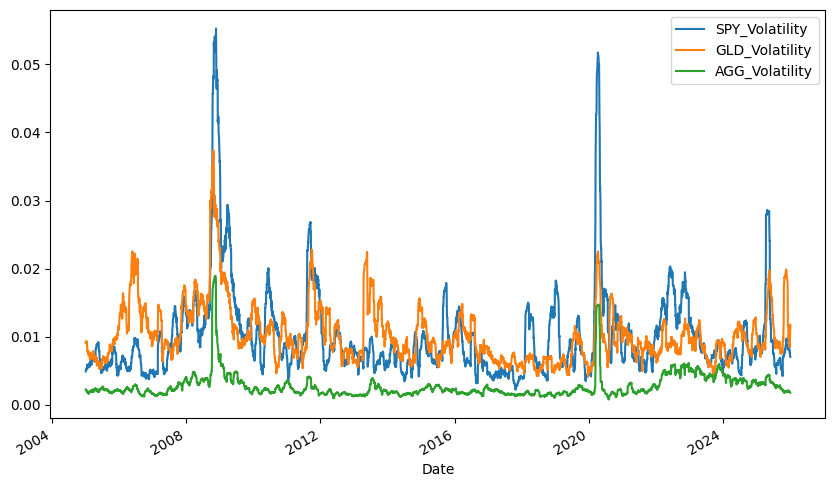

In [19]:
volatility.set_index("Date")[["SPY_Volatility","GLD_Volatility","AGG_Volatility"]].plot(figsize=(10, 6))

In [20]:
drawdown = volatility.copy()

spy_peak = prices["SPY_Close"].cummax()
gld_peak = prices["GLD_Close"].cummax()
agg_peak = prices["AGG_Close"].cummax()

drawdown["SPY_Drawdown"] = (prices["SPY_Close"] - spy_peak) / spy_peak
drawdown["GLD_Drawdown"] = (prices["GLD_Close"] - gld_peak) / gld_peak
drawdown["AGG_Drawdown"] = (prices["AGG_Close"] - agg_peak) / agg_peak
drawdown

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Returns,GLD_Returns,AGG_Returns,SPY_Volatility,GLD_Volatility,AGG_Volatility,SPY_Drawdown,GLD_Drawdown,AGG_Drawdown
0,2004-11-18,79.950714,44.380001,51.956501,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
1,2004-11-19,79.061928,44.779999,51.850304,-0.011117,0.009013,-0.002044,NaN,NaN,NaN,-0.011117,0.000000,-0.002044
2,2004-11-22,79.438957,44.950001,51.931271,0.004769,0.003796,0.001562,NaN,NaN,NaN,-0.006401,0.000000,-0.000486
3,2004-11-23,79.560158,44.750000,51.900871,0.001526,-0.004449,-0.000585,NaN,NaN,NaN,-0.004885,-0.004449,-0.001071
4,2004-11-24,79.748703,45.049999,51.951488,0.002370,0.006704,0.000975,NaN,NaN,NaN,-0.002527,0.000000,-0.000096
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5307,2025-12-23,686.086304,413.640015,98.829422,0.004570,0.013252,0.000000,0.007670,0.008527,0.001904,0.000000,0.000000,-0.024661
5308,2025-12-24,688.499695,411.929993,99.047279,0.003518,-0.004134,0.002204,0.007684,0.008624,0.001867,0.000000,-0.004134,-0.022511
5309,2025-12-26,688.429871,416.739990,99.067093,-0.000101,0.011677,0.000200,0.007685,0.008422,0.001865,-0.000101,0.000000,-0.022316
5310,2025-12-29,685.976562,398.600006,99.185928,-0.003564,-0.043528,0.001200,0.007027,0.011786,0.001781,-0.003665,-0.043528,-0.021143


<Axes: xlabel='Date'>

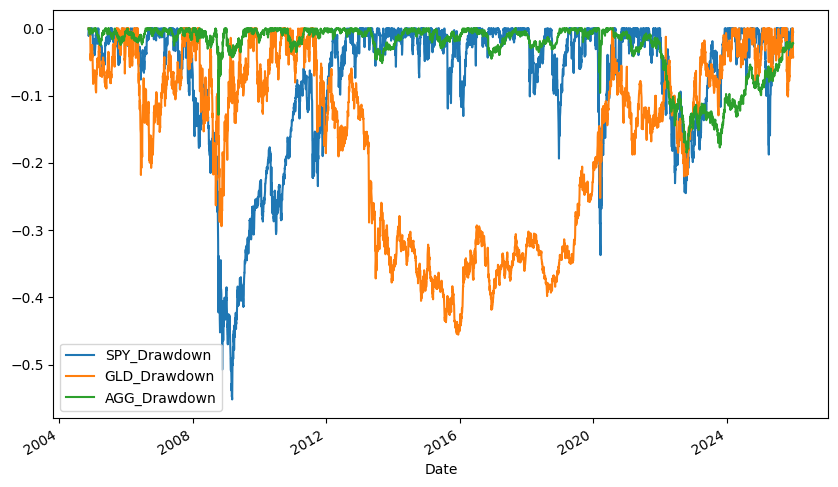

In [21]:
drawdown.set_index("Date")[["SPY_Drawdown","GLD_Drawdown","AGG_Drawdown"]].plot(figsize=(10,6))

In [22]:
market_daily = prices.copy()

market_daily = market_daily.merge(
    returns[["Date","SPY_Returns","GLD_Returns","AGG_Returns"]],
    on="Date"
)

market_daily = market_daily.merge(
    volatility[["Date","SPY_Volatility","GLD_Volatility","AGG_Volatility"]],
    on="Date"
)

market_daily = market_daily.merge(
    drawdown[["Date","SPY_Drawdown","GLD_Drawdown","AGG_Drawdown"]],
    on="Date"
)

market_daily

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Returns,GLD_Returns,AGG_Returns,SPY_Volatility,GLD_Volatility,AGG_Volatility,SPY_Drawdown,GLD_Drawdown,AGG_Drawdown
0,2004-11-18,79.950714,44.380001,51.956501,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
1,2004-11-19,79.061928,44.779999,51.850304,-0.011117,0.009013,-0.002044,NaN,NaN,NaN,-0.011117,0.000000,-0.002044
2,2004-11-22,79.438957,44.950001,51.931271,0.004769,0.003796,0.001562,NaN,NaN,NaN,-0.006401,0.000000,-0.000486
3,2004-11-23,79.560158,44.750000,51.900871,0.001526,-0.004449,-0.000585,NaN,NaN,NaN,-0.004885,-0.004449,-0.001071
4,2004-11-24,79.748703,45.049999,51.951488,0.002370,0.006704,0.000975,NaN,NaN,NaN,-0.002527,0.000000,-0.000096
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5307,2025-12-23,686.086304,413.640015,98.829422,0.004570,0.013252,0.000000,0.007670,0.008527,0.001904,0.000000,0.000000,-0.024661
5308,2025-12-24,688.499695,411.929993,99.047279,0.003518,-0.004134,0.002204,0.007684,0.008624,0.001867,0.000000,-0.004134,-0.022511
5309,2025-12-26,688.429871,416.739990,99.067093,-0.000101,0.011677,0.000200,0.007685,0.008422,0.001865,-0.000101,0.000000,-0.022316
5310,2025-12-29,685.976562,398.600006,99.185928,-0.003564,-0.043528,0.001200,0.007027,0.011786,0.001781,-0.003665,-0.043528,-0.021143


In [23]:
prices.to_csv("market_daily_features.csv", index=False)

Monthly data

In [24]:
market_daily["Date"] = pd.to_datetime(market_daily["Date"])
market_daily = market_daily.set_index("Date")
market_daily

,SPY_Close,GLD_Close,AGG_Close,SPY_Returns,GLD_Returns,AGG_Returns,SPY_Volatility,GLD_Volatility,AGG_Volatility,SPY_Drawdown,GLD_Drawdown,AGG_Drawdown
Date,,,,,,,,,,,,
2004-11-18,79.950714,44.380001,51.956501,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
2004-11-19,79.061928,44.779999,51.850304,-0.011117,0.009013,-0.002044,NaN,NaN,NaN,-0.011117,0.000000,-0.002044
2004-11-22,79.438957,44.950001,51.931271,0.004769,0.003796,0.001562,NaN,NaN,NaN,-0.006401,0.000000,-0.000486
2004-11-23,79.560158,44.750000,51.900871,0.001526,-0.004449,-0.000585,NaN,NaN,NaN,-0.004885,-0.004449,-0.001071
2004-11-24,79.748703,45.049999,51.951488,0.002370,0.006704,0.000975,NaN,NaN,NaN,-0.002527,0.000000,-0.000096
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,686.086304,413.640015,98.829422,0.004570,0.013252,0.000000,0.007670,0.008527,0.001904,0.000000,0.000000,-0.024661
2025-12-24,688.499695,411.929993,99.047279,0.003518,-0.004134,0.002204,0.007684,0.008624,0.001867,0.000000,-0.004134,-0.022511
2025-12-26,688.429871,416.739990,99.067093,-0.000101,0.011677,0.000200,0.007685,0.008422,0.001865,-0.000101,0.000000,-0.022316


In [25]:
monthly_prices = market_daily[["SPY_Close","GLD_Close","AGG_Close"]].resample("ME").last()
monthly_prices

,SPY_Close,GLD_Close,AGG_Close
Date,,,
2004-11-30,79.378349,45.119999,51.683456
2004-12-31,81.769333,43.799999,52.095558
2005-01-31,79.935989,42.220001,52.349884
2005-02-28,81.606995,43.529999,52.155495
2005-03-31,80.114166,42.820000,51.647354
...,...,...,...
2025-08-31,639.624573,318.070007,96.893364
2025-09-30,662.408264,355.470001,97.985130
2025-10-31,678.198303,368.119995,98.588188


In [26]:
monthly_returns = monthly_prices.pct_change()
monthly_returns.columns = ["SPY_Return_M","GLD_Return_M","AGG_Return_M"]
monthly_returns

,SPY_Return_M,GLD_Return_M,AGG_Return_M
Date,,,
2004-11-30,NaN,NaN,NaN
2004-12-31,0.030121,-0.029255,0.007974
2005-01-31,-0.022421,-0.036073,0.004882
2005-02-28,0.020904,0.031028,-0.003713
2005-03-31,-0.018293,-0.016311,-0.009743
...,...,...,...
2025-08-31,0.020520,0.049875,0.011904
2025-09-30,0.035620,0.117584,0.011268
2025-10-31,0.023837,0.035587,0.006155


In [27]:
monthly_volatility = market_daily[["SPY_Returns","GLD_Returns","AGG_Returns"]].resample("M").std()
monthly_volatility.columns = ["SPY_Vol_M","GLD_Vol_M","AGG_Vol_M"]
monthly_volatility

/tmp/ipykernel_2424/3974603123.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volatility = market_daily[["SPY_Returns","GLD_Returns","AGG_Returns"]].resample("M").std()


,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M
Date,,,
2004-11-30,0.005306,0.005673,0.001835
2004-12-31,0.004721,0.009541,0.002409
2005-01-31,0.006282,0.007961,0.001673
2005-02-28,0.006800,0.006940,0.002087
2005-03-31,0.006615,0.007335,0.002144
...,...,...,...
2025-08-31,0.007543,0.007538,0.002709
2025-09-30,0.004521,0.008564,0.002283
2025-10-31,0.008631,0.020985,0.002015


In [28]:
market_monthly = monthly_prices.copy()

market_monthly = market_monthly.merge(
    monthly_returns,
    left_index=True,
    right_index=True
)

market_monthly = market_monthly.merge(
    monthly_volatility,
    left_index=True,
    right_index=True
)

market_monthly

,SPY_Close,GLD_Close,AGG_Close,SPY_Return_M,GLD_Return_M,AGG_Return_M,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M
Date,,,,,,,,,
2004-11-30,79.378349,45.119999,51.683456,NaN,NaN,NaN,0.005306,0.005673,0.001835
2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409
2005-01-31,79.935989,42.220001,52.349884,-0.022421,-0.036073,0.004882,0.006282,0.007961,0.001673
2005-02-28,81.606995,43.529999,52.155495,0.020904,0.031028,-0.003713,0.006800,0.006940,0.002087
2005-03-31,80.114166,42.820000,51.647354,-0.018293,-0.016311,-0.009743,0.006615,0.007335,0.002144
...,...,...,...,...,...,...,...,...,...
2025-08-31,639.624573,318.070007,96.893364,0.020520,0.049875,0.011904,0.007543,0.007538,0.002709
2025-09-30,662.408264,355.470001,97.985130,0.035620,0.117584,0.011268,0.004521,0.008564,0.002283
2025-10-31,678.198303,368.119995,98.588188,0.023837,0.035587,0.006155,0.008631,0.020985,0.002015


In [29]:
market_monthly = market_monthly.dropna()

In [30]:
market_monthly = market_monthly.reset_index()

In [31]:
market_monthly

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Return_M,GLD_Return_M,AGG_Return_M,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M
0,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409
1,2005-01-31,79.935989,42.220001,52.349884,-0.022421,-0.036073,0.004882,0.006282,0.007961,0.001673
2,2005-02-28,81.606995,43.529999,52.155495,0.020904,0.031028,-0.003713,0.006800,0.006940,0.002087
3,2005-03-31,80.114166,42.820000,51.647354,-0.018293,-0.016311,-0.009743,0.006615,0.007335,0.002144
4,2005-04-30,78.613190,43.349998,52.537159,-0.018735,0.012377,0.017228,0.009656,0.006222,0.002309
...,...,...,...,...,...,...,...,...,...,...
248,2025-08-31,639.624573,318.070007,96.893364,0.020520,0.049875,0.011904,0.007543,0.007538,0.002709
249,2025-09-30,662.408264,355.470001,97.985130,0.035620,0.117584,0.011268,0.004521,0.008564,0.002283
250,2025-10-31,678.198303,368.119995,98.588188,0.023837,0.035587,0.006155,0.008631,0.020985,0.002015
251,2025-11-30,679.520813,387.880005,99.185349,0.001950,0.053678,0.006057,0.009668,0.011557,0.001812


In [32]:
market_monthly.to_csv("market_monthly_features.csv", index=False)

In [33]:
num_investors = 250

# weights = np.random.dirichlet(np.ones(3), size=num_investors)
# num_random = 200

random_weights = np.random.dirichlet(np.ones(3), size=num_investors)

extreme_portfolios = np.array([
    [1.0,0.0,0.0],
    [0.9,0.05,0.05],
    [0.8,0.1,0.1],
    [0.7,0.2,0.1],
    [0.2,0.1,0.7],
    [0.1,0.1,0.8],
    [0.05,0.1,0.85]
])

extreme_weights = np.repeat(extreme_portfolios,15,axis=0)

weights = np.vstack([random_weights, extreme_weights])

investor_portfolios = pd.DataFrame(weights, columns=["SPY_weight","GLD_weight","AGG_weight"])

investor_portfolios["Investor_ID"] = ["Investor_" + str(i+1) for i in range(num_investors+105)]

investor_portfolios = investor_portfolios[["Investor_ID","SPY_weight","GLD_weight","AGG_weight"]]
investor_portfolios

,Investor_ID,SPY_weight,GLD_weight,AGG_weight
0,Investor_1,0.122007,0.697217,0.180775
1,Investor_2,0.338158,0.183277,0.478565
2,Investor_3,0.446667,0.089588,0.463744
3,Investor_4,0.066235,0.425821,0.507944
4,Investor_5,0.223618,0.630900,0.145482
...,...,...,...,...
350,Investor_351,0.050000,0.100000,0.850000
351,Investor_352,0.050000,0.100000,0.850000
352,Investor_353,0.050000,0.100000,0.850000
353,Investor_354,0.050000,0.100000,0.850000


In [34]:
investor_portfolios["Total"] = investor_portfolios[["SPY_weight","GLD_weight","AGG_weight"]].sum(axis=1)

print(investor_portfolios["Total"].describe())

count    3.550000e+02
mean     1.000000e+00
std      8.303118e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: Total, dtype: float64


In [35]:
investor_portfolios.to_csv("investor_portfolios.csv", index=False)

In [36]:
portfolio_dataset = market_monthly.merge(investor_portfolios, how="cross")
portfolio_dataset

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Return_M,GLD_Return_M,AGG_Return_M,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M,Investor_ID,SPY_weight,GLD_weight,AGG_weight,Total
0,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_1,0.122007,0.697217,0.180775,1.0
1,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_2,0.338158,0.183277,0.478565,1.0
2,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_3,0.446667,0.089588,0.463744,1.0
3,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_4,0.066235,0.425821,0.507944,1.0
4,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_5,0.223618,0.630900,0.145482,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89810,2025-12-31,685.138916,398.890015,99.146317,0.008268,0.028385,-0.000394,0.005329,0.012375,0.001922,Investor_351,0.050000,0.100000,0.850000,1.0
89811,2025-12-31,685.138916,398.890015,99.146317,0.008268,0.028385,-0.000394,0.005329,0.012375,0.001922,Investor_352,0.050000,0.100000,0.850000,1.0
89812,2025-12-31,685.138916,398.890015,99.146317,0.008268,0.028385,-0.000394,0.005329,0.012375,0.001922,Investor_353,0.050000,0.100000,0.850000,1.0
89813,2025-12-31,685.138916,398.890015,99.146317,0.008268,0.028385,-0.000394,0.005329,0.012375,0.001922,Investor_354,0.050000,0.100000,0.850000,1.0


In [37]:
portfolio_dataset["Portfolio_Return"] = (
    portfolio_dataset["SPY_weight"] * portfolio_dataset["SPY_Return_M"] +
    portfolio_dataset["GLD_weight"] * portfolio_dataset["GLD_Return_M"] +
    portfolio_dataset["AGG_weight"] * portfolio_dataset["AGG_Return_M"]
)
portfolio_dataset

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Return_M,GLD_Return_M,AGG_Return_M,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M,Investor_ID,SPY_weight,GLD_weight,AGG_weight,Total,Portfolio_Return
0,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_1,0.122007,0.697217,0.180775,1.0,-0.015281
1,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_2,0.338158,0.183277,0.478565,1.0,0.008640
2,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_3,0.446667,0.089588,0.463744,1.0,0.014531
3,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_4,0.066235,0.425821,0.507944,1.0,-0.006412
4,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_5,0.223618,0.630900,0.145482,1.0,-0.010562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89810,2025-12-31,685.138916,398.890015,99.146317,0.008268,0.028385,-0.000394,0.005329,0.012375,0.001922,Investor_351,0.050000,0.100000,0.850000,1.0,0.002917
89811,2025-12-31,685.138916,398.890015,99.146317,0.008268,0.028385,-0.000394,0.005329,0.012375,0.001922,Investor_352,0.050000,0.100000,0.850000,1.0,0.002917
89812,2025-12-31,685.138916,398.890015,99.146317,0.008268,0.028385,-0.000394,0.005329,0.012375,0.001922,Investor_353,0.050000,0.100000,0.850000,1.0,0.002917
89813,2025-12-31,685.138916,398.890015,99.146317,0.008268,0.028385,-0.000394,0.005329,0.012375,0.001922,Investor_354,0.050000,0.100000,0.850000,1.0,0.002917


In [38]:
portfolio_dataset = portfolio_dataset.sort_values(["Investor_ID","Date"])

In [39]:
portfolio_dataset["Portfolio_Volatility"] = (
    portfolio_dataset
    .groupby("Investor_ID")["Portfolio_Return"]
    .rolling(window=6)
    .std()
    .reset_index(level=0, drop=True)
)

In [40]:
portfolio_dataset

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Return_M,GLD_Return_M,AGG_Return_M,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M,Investor_ID,SPY_weight,GLD_weight,AGG_weight,Total,Portfolio_Return,Portfolio_Volatility
0,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_1,0.122007,0.697217,0.180775,1.0,-0.015281,NaN
355,2005-01-31,79.935989,42.220001,52.349884,-0.022421,-0.036073,0.004882,0.006282,0.007961,0.001673,Investor_1,0.122007,0.697217,0.180775,1.0,-0.027004,NaN
710,2005-02-28,81.606995,43.529999,52.155495,0.020904,0.031028,-0.003713,0.006800,0.006940,0.002087,Investor_1,0.122007,0.697217,0.180775,1.0,0.023512,NaN
1065,2005-03-31,80.114166,42.820000,51.647354,-0.018293,-0.016311,-0.009743,0.006615,0.007335,0.002144,Investor_1,0.122007,0.697217,0.180775,1.0,-0.015365,NaN
1420,2005-04-30,78.613190,43.349998,52.537159,-0.018735,0.012377,0.017228,0.009656,0.006222,0.002309,Investor_1,0.122007,0.697217,0.180775,1.0,0.009458,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88138,2025-08-31,639.624573,318.070007,96.893364,0.020520,0.049875,0.011904,0.007543,0.007538,0.002709,Investor_99,0.518470,0.374627,0.106903,1.0,0.030596,0.011412
88493,2025-09-30,662.408264,355.470001,97.985130,0.035620,0.117584,0.011268,0.004521,0.008564,0.002283,Investor_99,0.518470,0.374627,0.106903,1.0,0.063723,0.018731
88848,2025-10-31,678.198303,368.119995,98.588188,0.023837,0.035587,0.006155,0.008631,0.020985,0.002015,Investor_99,0.518470,0.374627,0.106903,1.0,0.026349,0.017652
89203,2025-11-30,679.520813,387.880005,99.185349,0.001950,0.053678,0.006057,0.009668,0.011557,0.001812,Investor_99,0.518470,0.374627,0.106903,1.0,0.021768,0.018135


In [41]:
portfolio_dataset["Cumulative_Return"] = (
    portfolio_dataset
    .groupby("Investor_ID")["Portfolio_Return"]
    .transform(lambda x: (1 + x).cumprod())
)

In [42]:
portfolio_dataset["Portfolio_Peak"] = (
    portfolio_dataset
    .groupby("Investor_ID")["Cumulative_Return"]
    .cummax()
)

In [43]:
portfolio_dataset["Portfolio_Drawdown"] = (
    portfolio_dataset["Cumulative_Return"] - portfolio_dataset["Portfolio_Peak"]
) / portfolio_dataset["Portfolio_Peak"]

In [44]:
portfolio_dataset

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Return_M,GLD_Return_M,AGG_Return_M,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M,Investor_ID,SPY_weight,GLD_weight,AGG_weight,Total,Portfolio_Return,Portfolio_Volatility,Cumulative_Return,Portfolio_Peak,Portfolio_Drawdown
0,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,Investor_1,0.122007,0.697217,0.180775,1.0,-0.015281,NaN,0.984719,0.984719,0.000000
355,2005-01-31,79.935989,42.220001,52.349884,-0.022421,-0.036073,0.004882,0.006282,0.007961,0.001673,Investor_1,0.122007,0.697217,0.180775,1.0,-0.027004,NaN,0.958128,0.984719,-0.027004
710,2005-02-28,81.606995,43.529999,52.155495,0.020904,0.031028,-0.003713,0.006800,0.006940,0.002087,Investor_1,0.122007,0.697217,0.180775,1.0,0.023512,NaN,0.980656,0.984719,-0.004126
1065,2005-03-31,80.114166,42.820000,51.647354,-0.018293,-0.016311,-0.009743,0.006615,0.007335,0.002144,Investor_1,0.122007,0.697217,0.180775,1.0,-0.015365,NaN,0.965588,0.984719,-0.019428
1420,2005-04-30,78.613190,43.349998,52.537159,-0.018735,0.012377,0.017228,0.009656,0.006222,0.002309,Investor_1,0.122007,0.697217,0.180775,1.0,0.009458,NaN,0.974721,0.984719,-0.010153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88138,2025-08-31,639.624573,318.070007,96.893364,0.020520,0.049875,0.011904,0.007543,0.007538,0.002709,Investor_99,0.518470,0.374627,0.106903,1.0,0.030596,0.011412,7.353776,7.353776,0.000000
88493,2025-09-30,662.408264,355.470001,97.985130,0.035620,0.117584,0.011268,0.004521,0.008564,0.002283,Investor_99,0.518470,0.374627,0.106903,1.0,0.063723,0.018731,7.822379,7.822379,0.000000
88848,2025-10-31,678.198303,368.119995,98.588188,0.023837,0.035587,0.006155,0.008631,0.020985,0.002015,Investor_99,0.518470,0.374627,0.106903,1.0,0.026349,0.017652,8.028488,8.028488,0.000000
89203,2025-11-30,679.520813,387.880005,99.185349,0.001950,0.053678,0.006057,0.009668,0.011557,0.001812,Investor_99,0.518470,0.374627,0.106903,1.0,0.021768,0.018135,8.203251,8.203251,0.000000


In [45]:
portfolio_dataset["Downside_Return"] = portfolio_dataset["Portfolio_Return"].clip(upper=0)

In [46]:
portfolio_dataset["Downside_Risk"] = (
    portfolio_dataset
    .groupby("Investor_ID")["Downside_Return"]
    .rolling(window=6)
    .std()
    .reset_index(level=0, drop=True)
)

In [47]:
portfolio_dataset

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Return_M,GLD_Return_M,AGG_Return_M,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M,...,GLD_weight,AGG_weight,Total,Portfolio_Return,Portfolio_Volatility,Cumulative_Return,Portfolio_Peak,Portfolio_Drawdown,Downside_Return,Downside_Risk
0,2004-12-31,81.769333,43.799999,52.095558,0.030121,-0.029255,0.007974,0.004721,0.009541,0.002409,...,0.697217,0.180775,1.0,-0.015281,NaN,0.984719,0.984719,0.000000,-0.015281,NaN
355,2005-01-31,79.935989,42.220001,52.349884,-0.022421,-0.036073,0.004882,0.006282,0.007961,0.001673,...,0.697217,0.180775,1.0,-0.027004,NaN,0.958128,0.984719,-0.027004,-0.027004,NaN
710,2005-02-28,81.606995,43.529999,52.155495,0.020904,0.031028,-0.003713,0.006800,0.006940,0.002087,...,0.697217,0.180775,1.0,0.023512,NaN,0.980656,0.984719,-0.004126,0.000000,NaN
1065,2005-03-31,80.114166,42.820000,51.647354,-0.018293,-0.016311,-0.009743,0.006615,0.007335,0.002144,...,0.697217,0.180775,1.0,-0.015365,NaN,0.965588,0.984719,-0.019428,-0.015365,NaN
1420,2005-04-30,78.613190,43.349998,52.537159,-0.018735,0.012377,0.017228,0.009656,0.006222,0.002309,...,0.697217,0.180775,1.0,0.009458,NaN,0.974721,0.984719,-0.010153,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88138,2025-08-31,639.624573,318.070007,96.893364,0.020520,0.049875,0.011904,0.007543,0.007538,0.002709,...,0.374627,0.106903,1.0,0.030596,0.011412,7.353776,7.353776,0.000000,0.000000,0.0
88493,2025-09-30,662.408264,355.470001,97.985130,0.035620,0.117584,0.011268,0.004521,0.008564,0.002283,...,0.374627,0.106903,1.0,0.063723,0.018731,7.822379,7.822379,0.000000,0.000000,0.0
88848,2025-10-31,678.198303,368.119995,98.588188,0.023837,0.035587,0.006155,0.008631,0.020985,0.002015,...,0.374627,0.106903,1.0,0.026349,0.017652,8.028488,8.028488,0.000000,0.000000,0.0
89203,2025-11-30,679.520813,387.880005,99.185349,0.001950,0.053678,0.006057,0.009668,0.011557,0.001812,...,0.374627,0.106903,1.0,0.021768,0.018135,8.203251,8.203251,0.000000,0.000000,0.0


In [48]:
portfolio_dataset = portfolio_dataset.dropna()
portfolio_dataset

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Return_M,GLD_Return_M,AGG_Return_M,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M,...,GLD_weight,AGG_weight,Total,Portfolio_Return,Portfolio_Volatility,Cumulative_Return,Portfolio_Peak,Portfolio_Drawdown,Downside_Return,Downside_Risk
1775,2005-05-31,81.146454,41.650002,52.971985,0.032224,-0.039216,0.008277,0.006012,0.005026,0.001785,...,0.697217,0.180775,1.0,-0.021914,0.019796,0.953361,0.984719,-0.031845,-0.021914,0.011171
2130,2005-06-30,81.269409,43.439999,53.436100,0.001515,0.042977,0.008762,0.005056,0.006202,0.002745,...,0.697217,0.180775,1.0,0.031733,0.024879,0.983614,0.984719,-0.001122,0.000000,0.012303
2485,2005-07-31,84.378876,42.820000,52.882809,0.038261,-0.014273,-0.010354,0.005189,0.006605,0.002118,...,0.697217,0.180775,1.0,-0.007155,0.021672,0.976576,0.984719,-0.008269,-0.007155,0.009364
2840,2005-08-31,83.587883,43.400002,53.507660,-0.009374,0.013545,0.011816,0.006201,0.007517,0.002102,...,0.697217,0.180775,1.0,0.010436,0.019820,0.986768,0.986768,0.000000,0.000000,0.009364
3195,2005-09-30,84.258728,46.700001,53.006550,0.008026,0.076037,-0.009365,0.005433,0.008538,0.001649,...,0.697217,0.180775,1.0,0.052300,0.026601,1.038377,1.038377,0.000000,0.000000,0.008838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88138,2025-08-31,639.624573,318.070007,96.893364,0.020520,0.049875,0.011904,0.007543,0.007538,0.002709,...,0.374627,0.106903,1.0,0.030596,0.011412,7.353776,7.353776,0.000000,0.000000,0.000000
88493,2025-09-30,662.408264,355.470001,97.985130,0.035620,0.117584,0.011268,0.004521,0.008564,0.002283,...,0.374627,0.106903,1.0,0.063723,0.018731,7.822379,7.822379,0.000000,0.000000,0.000000
88848,2025-10-31,678.198303,368.119995,98.588188,0.023837,0.035587,0.006155,0.008631,0.020985,0.002015,...,0.374627,0.106903,1.0,0.026349,0.017652,8.028488,8.028488,0.000000,0.000000,0.000000
89203,2025-11-30,679.520813,387.880005,99.185349,0.001950,0.053678,0.006057,0.009668,0.011557,0.001812,...,0.374627,0.106903,1.0,0.021768,0.018135,8.203251,8.203251,0.000000,0.000000,0.000000


In [49]:
np.random.seed(42)

portfolio_dataset["Investment_Horizon"] = np.random.randint(
    1, 20,
    size=len(portfolio_dataset)
)

/tmp/ipykernel_2424/469828987.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  portfolio_dataset["Investment_Horizon"] = np.random.randint(


In [50]:
portfolio_dataset["Equity_Horizon_Risk"] = (
    portfolio_dataset["SPY_weight"] *
    (1 / np.sqrt(portfolio_dataset["Investment_Horizon"]))
)

# portfolio_dataset["Equity_Horizon_Risk"] = (
#     portfolio_dataset["SPY_weight"] *
#     (1 / portfolio_dataset["Investment_Horizon"])
# )

/tmp/ipykernel_2424/3796552046.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  portfolio_dataset["Equity_Horizon_Risk"] = (


In [51]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

risk_features = portfolio_dataset[[
    "Portfolio_Volatility",
    "Portfolio_Drawdown",
    "Downside_Risk"
]]

scaled_risk = scaler.fit_transform(risk_features)

scaled_risk = pd.DataFrame(
    scaled_risk,
    columns=[
        "Volatility_scaled",
        "Drawdown_scaled",
        "Downside_scaled"
    ]
)

portfolio_dataset = pd.concat(
    [portfolio_dataset.reset_index(drop=True), scaled_risk],
    axis=1
)
# joblib.dump(scaler, "risk_scaler.pkl")

In [52]:
portfolio_dataset["Drawdown_scaled"] = portfolio_dataset["Drawdown_scaled"].abs()

In [53]:
portfolio_dataset["Concentration"] = (
    portfolio_dataset["SPY_weight"]**2 +
    portfolio_dataset["GLD_weight"]**2 +
    portfolio_dataset["AGG_weight"]**2
)

In [54]:
portfolio_dataset["Diversification"] = 1 - portfolio_dataset["Concentration"]

In [55]:
portfolio_dataset["Risk_Score"] = (
    0.35 * portfolio_dataset["Volatility_scaled"] +
    0.25 * portfolio_dataset["Drawdown_scaled"] +
    0.15 * portfolio_dataset["Downside_scaled"] +
    0.25 * portfolio_dataset["Concentration"]
)
# portfolio_dataset["Horizon_Adjustment"] = (
#     1 / np.sqrt(portfolio_dataset["Investment_Horizon"])
# )

# portfolio_dataset["Risk_Score"] = (
#     0.35 * portfolio_dataset["Volatility_scaled"] +
#     0.25 * portfolio_dataset["Drawdown_scaled"] +
#     0.15 * portfolio_dataset["Downside_scaled"] +
#     0.25 * portfolio_dataset["Concentration"]
# ) * portfolio_dataset["Horizon_Adjustment"]

In [56]:
portfolio_dataset["Risk_Score_Percent"] = portfolio_dataset["Risk_Score"] * 100

In [57]:
def risk_category(score):

    if score < 20:
        return "Very Low"

    elif score < 40:
        return "Low"

    elif score < 60:
        return "Moderate"

    elif score < 80:
        return "High"

    else:
        return "Very High"

portfolio_dataset["Risk_Level"] = portfolio_dataset["Risk_Score_Percent"].apply(risk_category)

In [58]:
stress_rows = portfolio_dataset[
    portfolio_dataset["Portfolio_Return"] < -0.08
]

stress_augmented = pd.concat([stress_rows]*10)  #changed 4->8

portfolio_dataset = pd.concat([portfolio_dataset, stress_augmented], ignore_index=True)

In [59]:
shock_data = portfolio_dataset.copy()

shock_data["Portfolio_Return"] *= 1.4
shock_data["Portfolio_Volatility"] *= 1.6
shock_data["Downside_Risk"] *= 1.5
shock_data["Portfolio_Drawdown"] *= 1.4

portfolio_dataset = pd.concat([portfolio_dataset, shock_data], ignore_index=True)

In [60]:
portfolio_dataset

,Date,SPY_Close,GLD_Close,AGG_Close,SPY_Return_M,GLD_Return_M,AGG_Return_M,SPY_Vol_M,GLD_Vol_M,AGG_Vol_M,...,Investment_Horizon,Equity_Horizon_Risk,Volatility_scaled,Drawdown_scaled,Downside_scaled,Concentration,Diversification,Risk_Score,Risk_Score_Percent,Risk_Level
0,2005-05-31,81.146454,41.650002,52.971985,0.032224,-0.039216,0.008277,0.006012,0.005026,0.001785,...,7,0.046114,0.166917,0.937294,0.165915,0.533678,0.466322,0.451051,45.105108,Moderate
1,2005-06-30,81.269409,43.439999,53.436100,0.001515,0.042977,0.008762,0.005056,0.006202,0.002745,...,15,0.031502,0.215797,0.997790,0.182725,0.533678,0.466322,0.485805,48.580452,Moderate
2,2005-07-31,84.378876,42.820000,52.882809,0.038261,-0.014273,-0.010354,0.005189,0.006605,0.002118,...,11,0.036787,0.184952,0.983718,0.139080,0.533678,0.466322,0.464944,46.494400,Moderate
3,2005-08-31,83.587883,43.400002,53.507660,-0.009374,0.013545,0.011816,0.006201,0.007517,0.002102,...,8,0.043136,0.167147,1.000000,0.139080,0.533678,0.466322,0.462783,46.278296,Moderate
4,2005-09-30,84.258728,46.700001,53.006550,0.008026,0.076037,-0.009365,0.005433,0.008538,0.001649,...,7,0.046114,0.232362,1.000000,0.131270,0.533678,0.466322,0.484437,48.443668,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190135,2011-09-30,87.579269,158.059998,74.236816,-0.069421,-0.110623,0.007706,0.018272,0.020942,0.002386,...,8,0.117777,0.496671,0.839356,0.472097,0.416576,0.583424,0.558632,55.863231,Moderate
190136,2008-10-31,70.241203,71.339996,57.934025,-0.165186,-0.161397,-0.022810,0.056572,0.028875,0.020753,...,1,0.514308,0.425748,0.583727,0.679733,0.389157,0.610843,0.494193,49.419260,Moderate
190137,2008-10-31,70.241203,71.339996,57.934025,-0.165186,-0.161397,-0.022810,0.056572,0.028875,0.020753,...,11,0.176652,0.518152,0.518592,0.810211,0.449874,0.550126,0.545001,54.500147,Moderate
190138,2008-10-31,70.241203,71.339996,57.934025,-0.165186,-0.161397,-0.022810,0.056572,0.028875,0.020753,...,1,0.492386,0.418163,0.597306,0.668878,0.377365,0.622635,0.490356,49.035629,Moderate


In [61]:
np.random.seed(42)

portfolio_dataset["Risk_Tolerance"] = np.random.choice(
    ["Low","Medium","High"],
    size=len(portfolio_dataset),
    p=[0.3,0.5,0.2]
)

portfolio_dataset["Panic_Threshold"] = np.random.uniform(0.05,0.25,len(portfolio_dataset))

portfolio_dataset["Exit_Tendency"] = np.random.uniform(0,1,len(portfolio_dataset))

portfolio_dataset["Rebalance_Frequency"] = np.random.choice(
    ["Rare","Quarterly","Monthly"],
    size=len(portfolio_dataset),
    p=[0.4,0.4,0.2]
)

In [62]:
risk_map = {"Low":0.2,"Medium":0.5,"High":0.8}
rebalance_map = {"Rare":0.2,"Quarterly":0.6,"Monthly":0.9}

portfolio_dataset["Risk_Tolerance_Score"] = portfolio_dataset["Risk_Tolerance"].map(risk_map)

portfolio_dataset["Rebalance_Score"] = portfolio_dataset["Rebalance_Frequency"].map(rebalance_map)

In [63]:
portfolio_dataset["Behavioral_Stability"] = (
    0.35 * portfolio_dataset["Risk_Tolerance_Score"] +
    0.25 * (1 - portfolio_dataset["Exit_Tendency"]) +
    0.25 * portfolio_dataset["Rebalance_Score"] +
    0.15 * (1 - portfolio_dataset["Panic_Threshold"])
)

In [64]:
portfolio_dataset["Behavioral_Stability"] = (
    portfolio_dataset["Behavioral_Stability"] * 100
)

In [65]:
portfolio_dataset["Hybrid_Risk"] = (
    0.75 * portfolio_dataset["Risk_Score_Percent"] +
    0.25 * (100 - portfolio_dataset["Behavioral_Stability"])
)

In [66]:
# portfolio_dataset.to_csv("portfolio_risk_dataset.csv", index=False)

In [67]:
features = [
"SPY_weight",
"GLD_weight",
"AGG_weight",
"Portfolio_Return",
"Portfolio_Volatility",
"Portfolio_Drawdown",
"Downside_Risk",
"Concentration",
"Diversification",
"Investment_Horizon",
"Equity_Horizon_Risk",
"Risk_Tolerance_Score",
"Exit_Tendency",
"Rebalance_Score",
"Panic_Threshold"
]

X = portfolio_dataset[features]

y = portfolio_dataset["Hybrid_Risk"]

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# from sklearn.ensemble import GradientBoostingRegressor

# model = GradientBoostingRegressor(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=4,
#     random_state=42
# )
# import joblib

# model = joblib.load("risk_prediction_model_rangeupdated.pkl")

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [70]:
y_pred = model.predict(X_test)
y_pred

array([49.52051751, 45.68292679, 51.08846922, ..., 43.87235908,
       40.75131241, 50.39188452])

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.0516253840028558
RMSE: 1.4116974589674909
R2: 0.9577853555733972


In [72]:
# metrics = pd.DataFrame({
#     "Model":["Random Forest","Gradient Boosting"],
#     "MAE":[1.07035093, mae],
#     "RMSE":[1.43970813, rmse],
#     "R2":[0.951305775, r2]
# })
# metrics

In [73]:
# import matplotlib.pyplot as plt

# metrics.set_index("Model")[["MAE","RMSE","R2"]].plot(
#     kind="bar",
#     figsize=(7,4)
# )

# plt.title("Model Performance Comparison")
# plt.ylabel("Score")
# plt.xticks(rotation=0)
# plt.legend(loc="upper right")
# plt.tight_layout()

# plt.show()

NameError: name 'metrics' is not defined

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

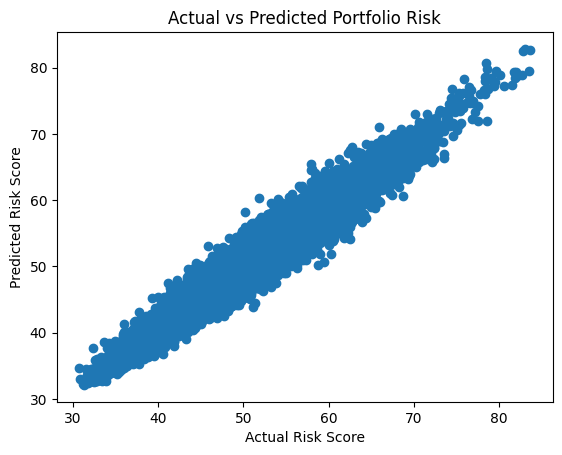

In [75]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")

plt.title("Actual vs Predicted Portfolio Risk")

plt.show()

Text(0.5, 1.0, 'Distribution of Hybrid Portfolio Risk')

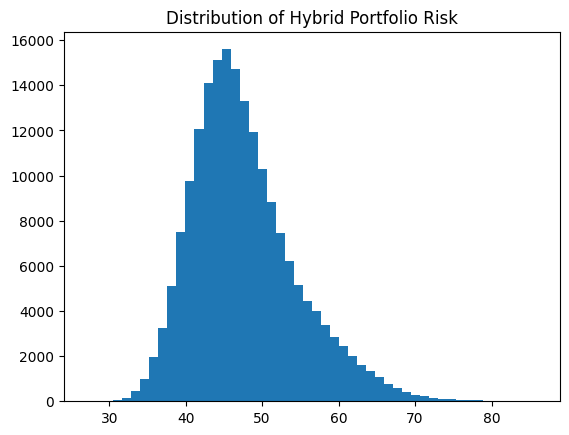

In [76]:
plt.hist(portfolio_dataset["Hybrid_Risk"], bins=50)
plt.title("Distribution of Hybrid Portfolio Risk")

In [ ]:
# import joblib
# # from google.colab import files
# joblib.dump(model, "risk_prediction_model_rangeupdated.pkl")

In [77]:
portfolio_dataset["Risk_Score_Percent"].describe()

,Risk_Score_Percent
count,190140.000000
mean,48.303944
std,8.224200
min,31.434064
25%,42.393735
50%,46.307400
75%,52.341986
max,95.247056


In [ ]:
# import joblib

# model = joblib.load("risk_prediction_model.pkl")

In [ ]:
# import pandas as pd

# input_data = pd.DataFrame({

# "SPY_weight":[1],
# "GLD_weight":[0],
# "AGG_weight":[0],

# "Portfolio_Return":[0.02],
# "Portfolio_Volatility":[0.05],
# "Portfolio_Drawdown":[-0.08],
# "Downside_Risk":[0.03],

# "Concentration":[0.7**2 + 0.2**2 + 0.1**2],
# "Investment_Horizon":1,
# "Equity_Horizon_Risk": 1,
# "Risk_Tolerance_Score":[0],
# "Exit_Tendency":[0],
# "Rebalance_Score":[0],
# "Panic_Threshold":[0.]

# })

In [ ]:
# prediction = model.predict(input_data)

# print("Predicted Portfolio Risk:", prediction[0], "%")